# Task 1A — Understanding the Dataset

**Dataset:** Walmart Recruiting - Store Sales Forecasting (Kaggle)
https://www.kaggle.com/c/walmart-recruiting-store-sales-forecasting

Weekly sales for 45 Walmart stores across 81 departments, joined with
store metadata (type, size) and store-week external features (temperature,
fuel price, CPI, unemployment, promotional markdowns).

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_raw, load_merged
from src.preprocessing import handle_missing, MARKDOWN_COLS

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

train, features, stores = load_raw()
merged = load_merged()
merged.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


## Dataset shape and structure

In [2]:
print("train.csv     :", train.shape)
print("features.csv  :", features.shape)
print("stores.csv    :", stores.shape)
print("merged (train + features + stores):", merged.shape)
merged.dtypes

train.csv     : (421570, 5)
features.csv  : (8190, 12)
stores.csv    : (45, 3)
merged (train + features + stores): (421570, 16)


Store                    int64
Dept                     int64
Date            datetime64[us]
Weekly_Sales           float64
IsHoliday                 bool
Temperature            float64
Fuel_Price             float64
MarkDown1              float64
MarkDown2              float64
MarkDown3              float64
MarkDown4              float64
MarkDown5              float64
CPI                    float64
Unemployment           float64
Type                       str
Size                     int64
dtype: object

## Time range and frequency

Each row is one **Store x Department x Week** observation. Retail weeks in
this dataset always land on a Friday.

In [3]:
date_diffs = np.sort(merged["Date"].unique())
step_days = np.diff(date_diffs).astype("timedelta64[D]").astype(int)

print("Start date:", merged["Date"].min().date())
print("End date  :", merged["Date"].max().date())
print("Total span:", (merged["Date"].max() - merged["Date"].min()).days, "days")
print("Number of distinct weekly timestamps:", len(date_diffs))
print("Unique day-of-week values:", merged["Date"].dt.day_name().unique())
print("Gap between consecutive timestamps (days) - unique values:", np.unique(step_days))
print("=> Frequency is a fixed WEEKLY cadence (7 days, always Friday), no missing calendar weeks.")

Start date: 2010-02-05
End date  : 2012-10-26
Total span: 994 days
Number of distinct weekly timestamps: 143


Unique day-of-week values: <StringArray>
['Friday']
Length: 1, dtype: str
Gap between consecutive timestamps (days) - unique values: [7]
=> Frequency is a fixed WEEKLY cadence (7 days, always Friday), no missing calendar weeks.


## Panel structure (stores / departments)

In [4]:
print("Unique stores:", merged["Store"].nunique())
print("Unique departments:", merged["Dept"].nunique())
print("Store-Dept combinations present:", merged.groupby(["Store", "Dept"]).ngroups)
print("Max possible combinations (45 x 81):", 45 * 81)
print("=> Not every store carries every department (it's an unbalanced panel).")

stores["Type"].value_counts()

Unique stores: 45
Unique departments: 81
Store-Dept combinations present: 3331
Max possible combinations (45 x 81): 3645
=> Not every store carries every department (it's an unbalanced panel).


Type
A    22
B    17
C     6
Name: count, dtype: int64

## Missing values

Two different missingness patterns show up, and they call for two
different handling strategies:

1. **MarkDown1-5** (promotional markdown amounts): Walmart's markdown
   program only started in **November 2011**, roughly two-thirds of the
   way through the dataset. Before that date every value is `NaN` because
   no such promotion existed yet — this is missing **not at random**, and
   it does not mean "unknown amount". We fill these with **0**, which
   faithfully encodes "no promotion ran that week" instead of inventing an
   average markdown that never happened.
2. **CPI / Unemployment**: these are slow-moving macroeconomic indicators
   published periodically per store/region. Any gaps are forward-filled
   within each store (carrying the latest known reading forward), which is
   a far better estimate for a slow-moving series than a global mean.

In [5]:
missing_counts = merged.isna().sum()
missing_pct = (missing_counts / len(merged) * 100).round(2)
missing_report = pd.DataFrame({"missing_count": missing_counts, "missing_pct": missing_pct})
missing_report = missing_report[missing_report["missing_count"] > 0].sort_values(
    "missing_pct", ascending=False
)
missing_report

,missing_count,missing_pct
MarkDown2,310322,73.61
MarkDown4,286603,67.98
MarkDown3,284479,67.48
MarkDown1,270889,64.26
MarkDown5,270138,64.08


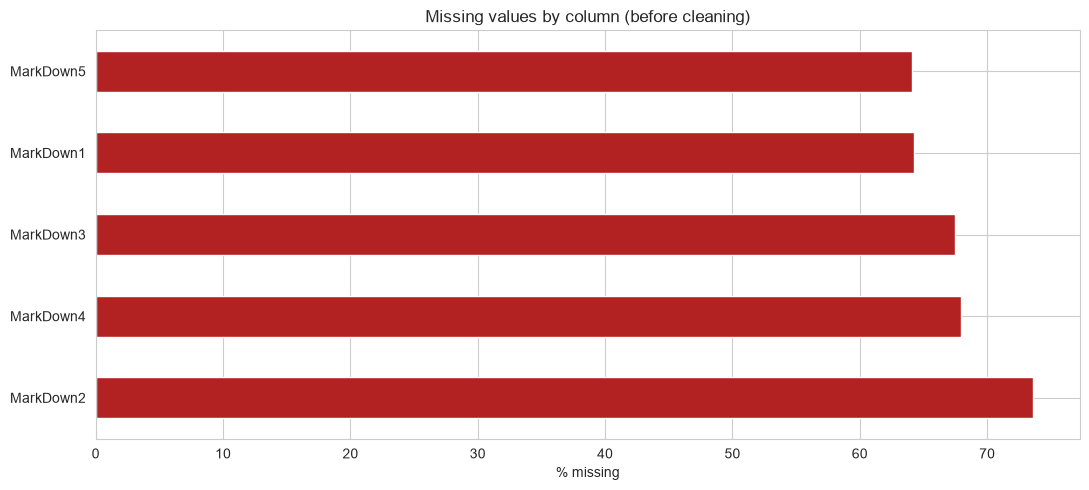

In [6]:
fig, ax = plt.subplots()
missing_report["missing_pct"].plot(kind="barh", ax=ax, color="firebrick")
ax.set_xlabel("% missing")
ax.set_title("Missing values by column (before cleaning)")
plt.tight_layout()
plt.savefig("../reports/figures/01_missing_values.png", dpi=120)
plt.show()

In [7]:
# Confirm the MarkDown missingness is time-boundary driven, not random
markdown_start = merged.loc[merged[MARKDOWN_COLS].notna().any(axis=1), "Date"].min()
print("First date any MarkDown value is present:", markdown_start.date())
print("=> Confirms MarkDown NaNs before this date are structural, not random dropout.")

First date any MarkDown value is present: 2011-11-11
=> Confirms MarkDown NaNs before this date are structural, not random dropout.


In [8]:
cleaned = handle_missing(merged)
print("Missing values remaining after cleaning:")
remaining = cleaned.isna().sum()
print(remaining[remaining > 0] if remaining.sum() else "None — all handled.")

cleaned.to_csv("../data/processed/walmart_merged_clean.csv", index=False)
print("\nSaved cleaned merged dataset -> data/processed/walmart_merged_clean.csv", cleaned.shape)

Missing values remaining after cleaning:
None — all handled.



Saved cleaned merged dataset -> data/processed/walmart_merged_clean.csv (421570, 16)


## Statistical distribution of numerical columns

In [9]:
numeric_cols = [
    "Weekly_Sales", "Temperature", "Fuel_Price", "CPI", "Unemployment", "Size"
] + MARKDOWN_COLS
cleaned[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Weekly_Sales,421570.0,15981.258123,22711.183519,-4988.940,2079.650000,7612.03000,20205.852500,693099.360000
Temperature,421570.0,60.090059,18.447931,-2.060,46.680000,62.09000,74.280000,100.140000
Fuel_Price,421570.0,3.361027,0.458515,2.472,2.933000,3.45200,3.738000,4.468000
CPI,421570.0,171.201947,39.159276,126.064,132.022667,182.31878,212.416993,227.232807
Unemployment,421570.0,7.960289,1.863296,3.879,6.891000,7.86600,8.572000,14.313000
Size,421570.0,136727.915739,60980.583328,34875.000,93638.000000,140167.00000,202505.000000,219622.000000
MarkDown1,421570.0,2590.074819,6052.385934,0.000,0.000000,0.00000,2809.050000,88646.760000
MarkDown2,421570.0,879.974298,5084.538801,-265.760,0.000000,0.00000,2.200000,104519.540000
MarkDown3,421570.0,468.087665,5528.873453,-29.100,0.000000,0.00000,4.540000,141630.610000
MarkDown4,421570.0,1083.132268,3894.529945,0.000,0.000000,0.00000,425.290000,67474.850000


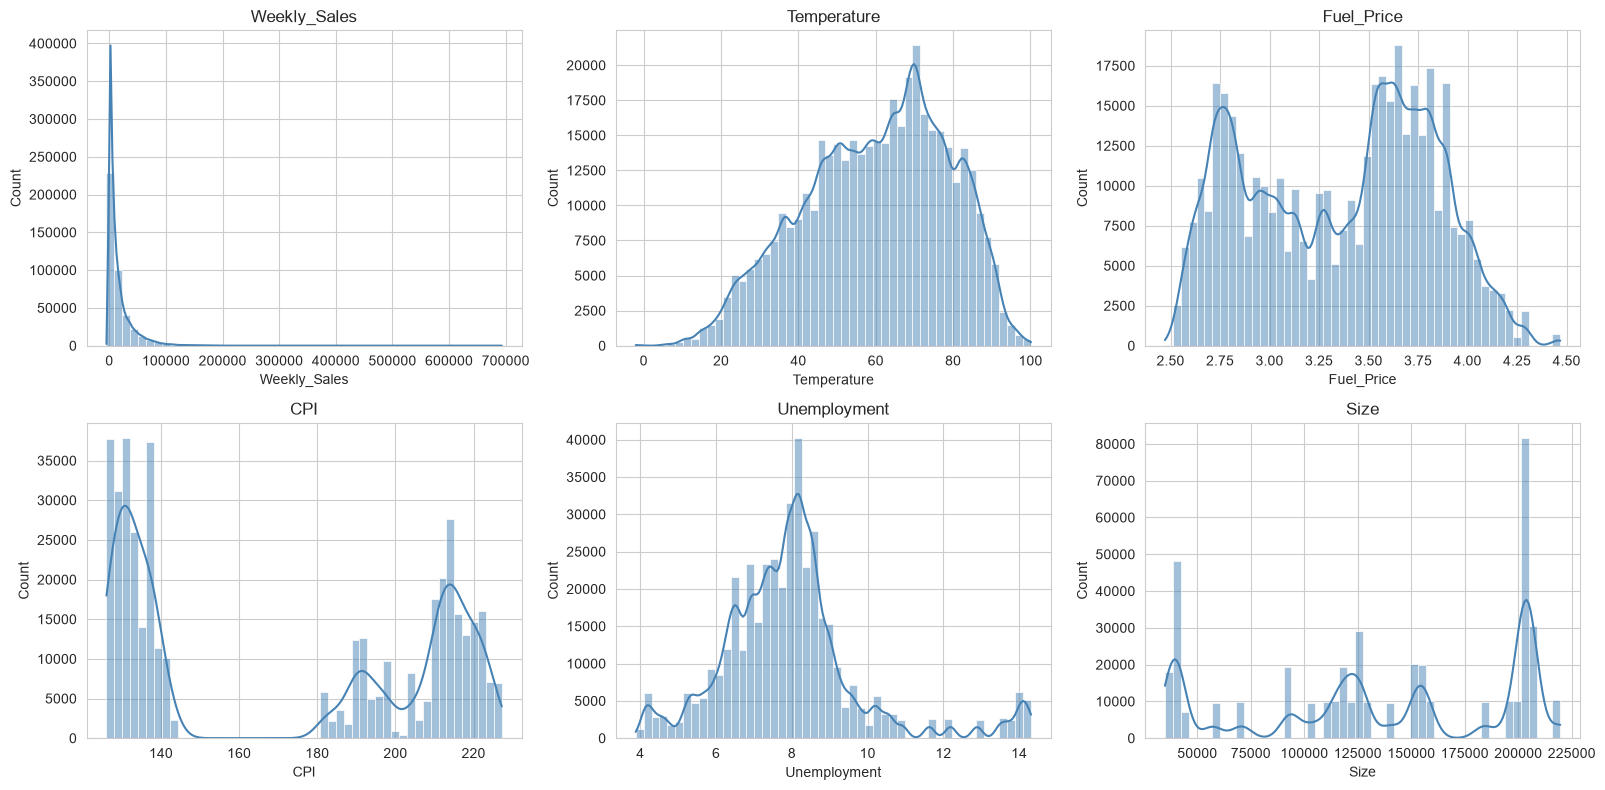

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.ravel(), ["Weekly_Sales", "Temperature", "Fuel_Price", "CPI", "Unemployment", "Size"]):
    sns.histplot(cleaned[col], bins=50, ax=ax, kde=True, color="steelblue")
    ax.set_title(col)
plt.tight_layout()
plt.savefig("../reports/figures/02_numeric_distributions.png", dpi=120)
plt.show()

**Observations:**
- `Weekly_Sales` is strongly right-skewed with a long tail of large
  holiday-week / large-store spikes, and a small number of negative values
  (likely return-heavy weeks) — worth flagging for modeling but not
  removing, since they are legitimate retail weeks, not sensor errors.
- `Temperature`, `Fuel_Price`, `CPI` show clear multi-modal/seasonal
  patterns consistent with a ~3-year span crossing multiple winters/summers
  and a structural CPI regime shift.
- `Size` (store square footage) is roughly trimodal, matching the three
  store `Type` categories (A/B/C).

In [11]:
print("Negative Weekly_Sales rows:", (cleaned["Weekly_Sales"] < 0).sum(),
      f"({(cleaned['Weekly_Sales'] < 0).mean()*100:.3f}% of rows)")

Negative Weekly_Sales rows: 1285 (0.305% of rows)
